The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[*********************100%***********************]  1 of 1 completed


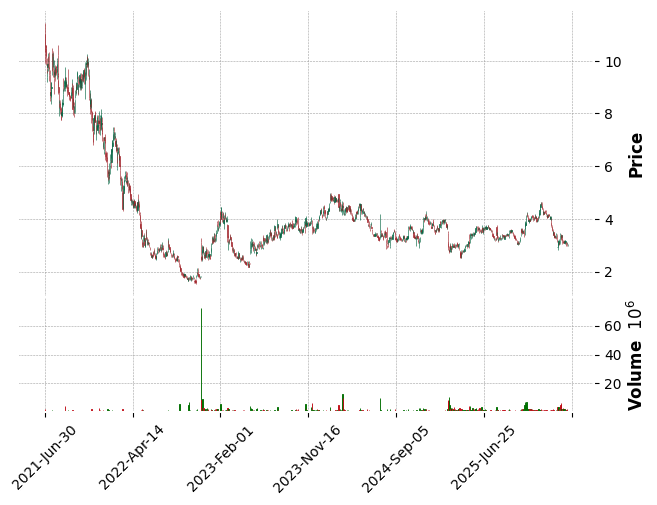

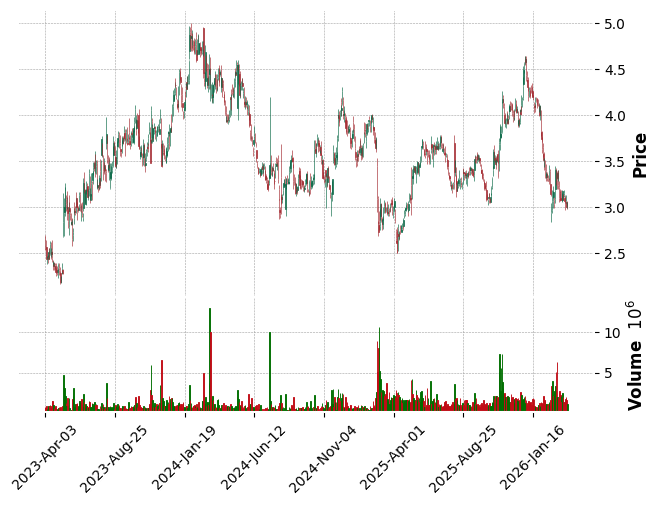

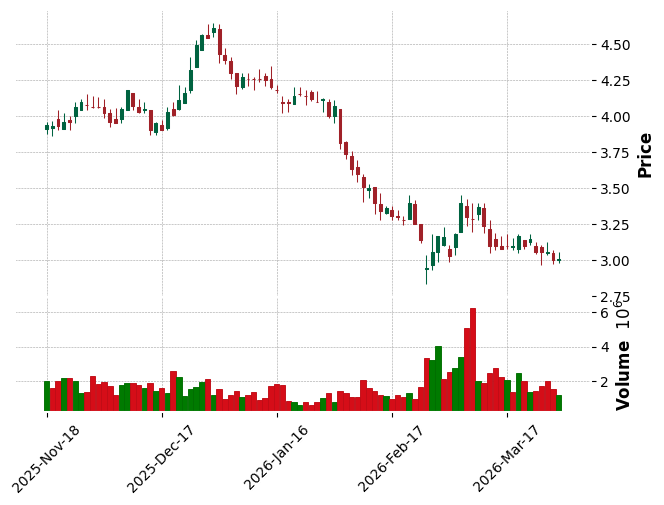

In [15]:
%load_ext autoreload
%autoreload 1
%aimport fundamentals

import finnhub
import pandas as pd
import json
from fundamentals import Fundamentals
import numpy as np
from itables import init_notebook_mode, options
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import mplfinance as mpf
import ipynbname
init_notebook_mode(all_interactive=True)
options.style = "table-layout:auto; width:50%;"
plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.2f}'.format)

# Setup client
# ASIX
name = ipynbname.name().strip('.ipynb').upper()
thirtyday = dt.datetime.now() - dt.timedelta(days=90)
stockName = 'TBLA'
Fun = Fundamentals(stockName, thirtyday.strftime('%Y-%m-%d'), dt.datetime.now().strftime('%Y-%m-%d'))

historical = Fun.get_history()
historical.columns = historical.columns.get_level_values(0)
mpf.plot(historical, type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-750:], type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-90:], type='candle', style='charles',volume=True)

In [16]:
funds = Fun.get_fundamentals()

funds

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


33.39615384615385


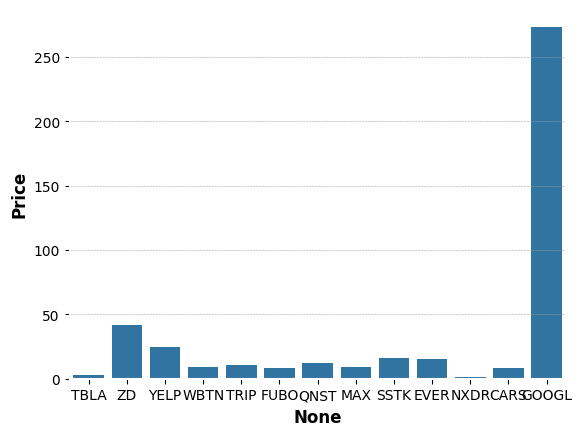

In [17]:
peers, avg_price = Fun.get_peers()
print(avg_price)
sns.barplot(x=peers.index, y=peers['Price'])
plt.show()

In [18]:
fairValues = Fun.caculateFairValues()

fairValues.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [19]:
other_metrics = Fun.get_other_metric()

other_metrics.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [20]:
insider_sentiment = Fun.get_insider_sentiment()
print(f"{insider_sentiment[0]}:")
print("")
print(insider_sentiment[1])

2025-12-31 2026-03-31
insider_signal:

Bullish (Net Buy): 5,184,867 shares


In [21]:
news = Fun.get_news()

for x in news:
    print(x['datetime'])
    print(x['headline'])
    print(x['summary'])
    print(x['url'])
    print("")

2026-03-06 06:04:40
Anthropic Unveils Amazon-Inspired Marketplace For AI Software
https://www.bloomberg.com/news/articles/2026-03-06/anthropic-unveils-amazon-inspired-marketplace-for-ai-software
https://finnhub.io/api/news?id=a005c41ea44461c05971030ee070e069693a13e785359059fe14a42628ceb6c6

2026-03-02 07:27:55
Taboola.com Ltd. (TBLA) Presents at Morgan Stanley Technology, Media & Telecom Conference 2026 Transcript

https://finnhub.io/api/news?id=abc657a413a28c66b3318fa9e757741972b870e79df8e14c807aa5485c8a1323

2026-02-27 03:10:24
'OpenAI's Sam Altman Calls for De-Escalation in Anthropic Showdown With Hegseth' - Wall Street Journal
https://www.wsj.com/tech/ai/openais-sam-altman-calls-for-de-escalation-in-anthropic-showdown-with-hegseth-03ecbac8
https://finnhub.io/api/news?id=bd21005b96b936a706656e3ef9bbd0ea67b67c0cdaf6cf67d3b66d2807f6750c

2026-02-27 02:46:38
'OpenAI Finalizes $110 Billion Funding at $730 Billion Valuation' - Bloomberg
https://www.bloomberg.com/news/articles/2026-02-27/

Average Weighted EPS: -0.0015
Lower Standard Deviation: -0.0840277545350353
Upper Standard Deviation: 0.0810277545350353
Total Debt/Total Equity: 0.1128


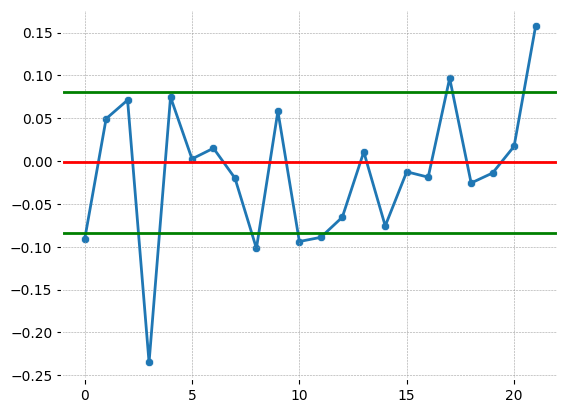

In [22]:
try:
    inflect = Fun.get_inflections()
except:
    pass

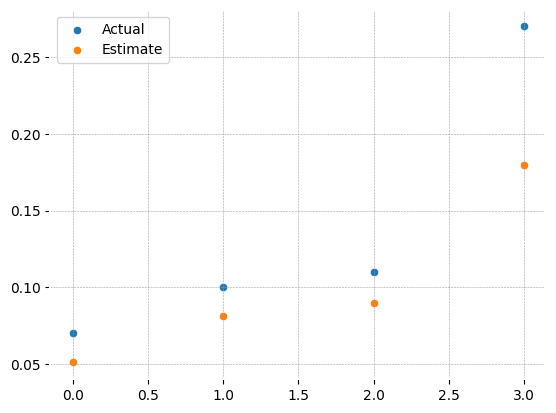

In [23]:
surprise = Fun.eps_surprise()

2021-12-31             NaN
2022-12-31   1401150000.00
2023-12-31   1439685000.00
2024-12-31   1766220000.00
2025-12-31   1912040000.00
Name: Total Revenue, dtype: float64
Revenue: [1.439685e+09 1.766220e+09 1.912040e+09]


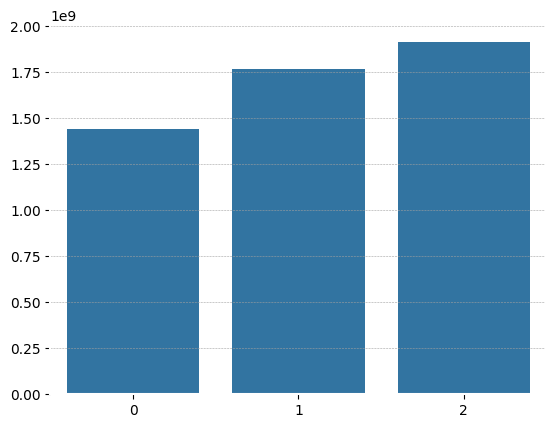

In [24]:
revenue = Fun.revenue_growth()

In [25]:
dcf = Fun.calculate_dcf()

Current FCF for TBLA: $163,446,000.00
{'Current Price': 3.01,
 'Enterprise Value': 2567594652.96,
 'Intrinsic Price': 10.08,
 'Ticker': 'TBLA'}


--- Profitability Analysis: TBLA ---

Annual Net Income History:
2021-12-31            NaN
2022-12-31   -11975000.00
2023-12-31   -82040000.00
2024-12-31    -3760000.00
2025-12-31    42284000.00
Name: Net Income, dtype: float64

Last 4 Quarters Net Income:
2025-03-31   -8750000.00
2025-06-30   -4345000.00
2025-09-30    5244000.00
2025-12-31   50135000.00
Name: Net Income, dtype: float64


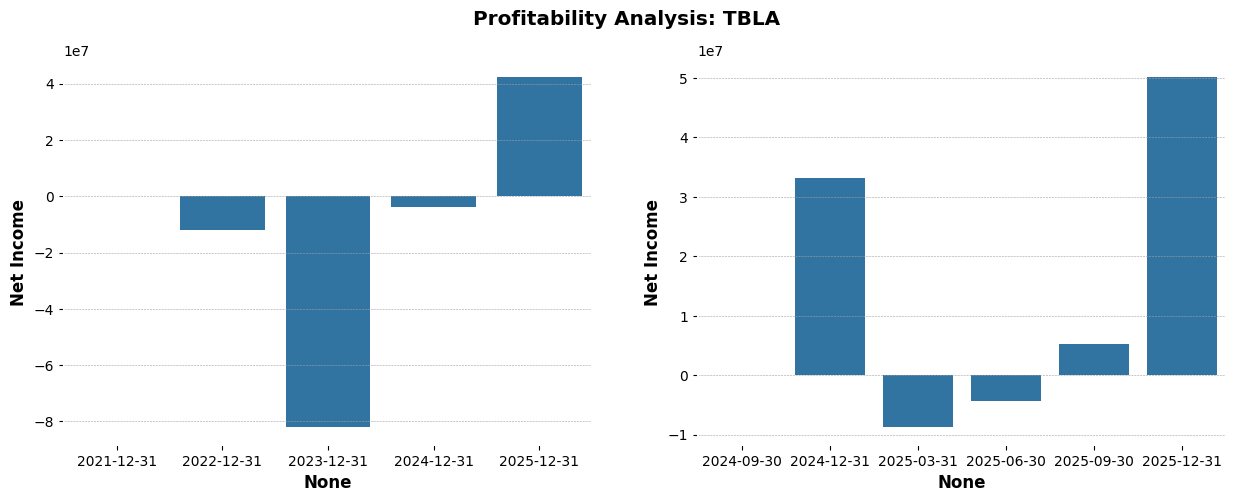

(2021-12-31            NaN
 2022-12-31   -11975000.00
 2023-12-31   -82040000.00
 2024-12-31    -3760000.00
 2025-12-31    42284000.00
 Name: Net Income, dtype: float64,
 2024-09-30           NaN
 2024-12-31   33143000.00
 2025-03-31   -8750000.00
 2025-06-30   -4345000.00
 2025-09-30    5244000.00
 2025-12-31   50135000.00
 Name: Net Income, dtype: float64)

In [26]:
Fun.check_profitability()

--- FCF Analysis for TBLA ---

Annual FCF Trend:
2021-12-31            NaN
2022-12-31    18570000.00
2023-12-31    52240000.00
2024-12-31   149176000.00
2025-12-31   163446000.00
Name: Free Cash Flow, dtype: float64


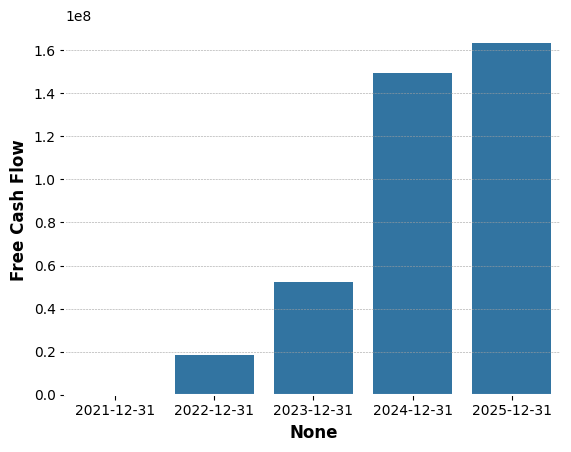

Annual Direction: INCREASING (14,270,000)

Quarterly FCF Trend (Last 4 Quarters):
2025-03-31   36070000.00
2025-06-30   34161000.00
2025-09-30   46289000.00
2025-12-31   46926000.00
Name: Free Cash Flow, dtype: float64


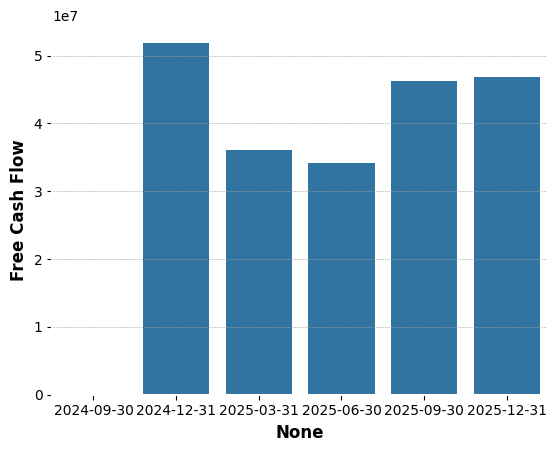

Recent Quarterly Direction: INCREASING (637,000)


In [27]:
Fun.check_fcf_trend()